In this notebook, i will learn about `Loss function` in a bit deeper way

# Loss functions
_A method of evaluating how well an algorithm is modeling your dataset_

Loss function is a function that tells how bad our model is performing, or how far the prediction is from true values. 

### Losses in Deep learning
| Task / Problem Type        | Common Loss Functions |
|---------------------------|-----------------------|
| Regression                | Mean Squared Error (MSE), Mean Absolute Error (MAE), Huber Loss |
| Binary Classification     | Binary Cross-Entropy, Hinge Loss |
| Multiclass Classification | Categorical Cross-Entropy |
| Autoencoders              | KL Divergence |
| Generative Adversarial Networks (GANs) | Discriminator Loss, Generator Loss, Minimax Loss |
| Object / Optical Detection | Focal Loss |
| Metric Learning / Embeddings | Triplet Loss |


### Loss/Error Function vs Cost Function
- Loss function measures error for a single instance
    - Represented as $L(y,\hat{y})$
- Cost function is avg (or sum) of losses over entire dataset
    - Represented as $J(\theta) = \frac{1}{n}\sum L(y,\hat{y})$



## Some Important Loss functions

### ___MSE___

- Mean Squared Error is square of difference between true value and predicted value

$$L(y,\hat{y}) = (y-\hat{y})^2$$

- Why Squared though? - So that negative errors does not cancel out postive errors in summation

| Advantages | Disadvantages |
|------------|---------------|
| Easy to interpret | Error does not have same unit as data |
| Continuous and Differentiable function|
| Only One minima (good for gradient descent) |
| Since this function is quadratic, higher the difference in true value and predicted value, higher the error, and hence more influence on weights and bais for next iteration in training| Sensitive to outliers - If data have outlier then obviously error will be huge, and squared error will be even greater, hence very high influence on weights and bais for next iteration (but we dont want that since we want model to work for general data and not outliers) |

- To applyer MSE, we can have any activation function in hidden layers but last neuron must have linear activation function

### ___MAE___

- Mean Absolute Error is absolute value of difference between true and predicted value

- $$L(y,\hat{y}) = |y-\hat{y}|$$

|Advantages|Disadvantages|
|----------|-----------|
|Easy to interpret| Non-differentiable function, so methods like GD cannot be used which rely heavily on differentiation. Instead subgradients are calculated, which increases the time complexity though|
|Robust to outliers|
|Unit of error is same as y|


### ___Huber Loss___
- It combines advantages of MSE and MAE. It is less sensitive to outliers and also differentiable function.

- Use it when data have many outliers that should not be ignored

$$
L(y,\hat{y}) = 
\begin{cases} 
\frac{1}{2}(y-\hat{y}) & \text{if} |y-\hat{y}| <= \delta
\\
\delta |y-\hat{y}| - \frac{1}{2}\delta^2 & \text{if} |y-\hat{y}|>\delta 
\end{cases}

$$

### ___Binary Cross Entropy___
- Binary cross entropy or Log Loss is used in binary classification problems

$$
L(y,\hat{y}) = -ylog(\hat{y}) - (1-y)log(1-\hat{y})
$$

- To use this loss use Sigmoid function for activation at the last neuron

Ex: $y=1$, $\hat{y}=0.73$ Then   
$L = -1 log(0.73) - 0 = 0.136$

Ex: $y=0, \hat{y}=0.4$ Then  
$L = 0 - (1-0)log(1-0.4) = 0.22$

|Advantages|Disadvantages|
|----------|-----------|
|Differentiable| Non-intuitive|
||Multiple minimas|

### Categorical cross entropy
- used for Multiclass classification 

$$
L(y,\hat{y}) = - \sum_{i=1}^{k}y_i log(\hat{y_i})
$$

- Where k = number of classes

Ex: For three classes  
$L(y,\hat{y}) = -y_1 log(\hat{y_1}) - y_2 log(\hat{y_2}) - y_3 log(\hat{y_3})$

- When using this, the output layer should have number of neurons same as number of classes 
- And activation function in output layer must be Softmax

- Note: To use this loss function we have to One Hot Encode the target label, so it looks something like this - 


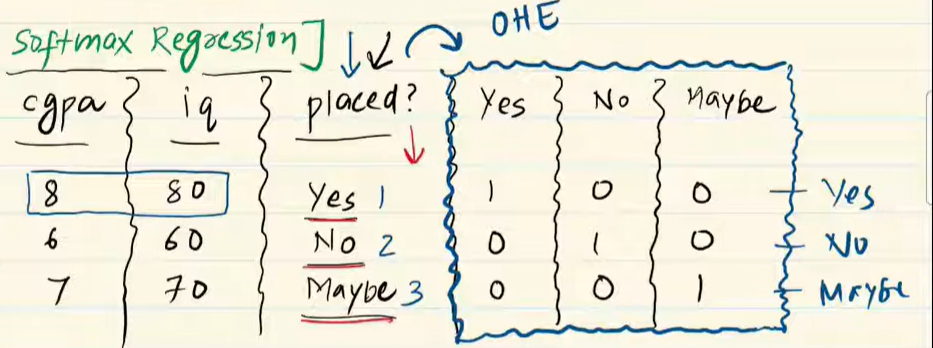

### Sparse Categorical Cross Entropy
- Similar to Categorical cross entropy, but we dont have to OHE the target label, instead we just give them a integer label (1,2,3...)
- Hence this is faster when working with many categories

$$
L(y,\hat{y}) = -log(\hat{y}_{y})
$$

- Where, y represents correct label
- This menas: take the predicted probability of only correct class and apply negative log.